In [3]:
import os
os.environ.setdefault("DLOMIX_BACKEND", "torch")
from dlomix.models.prosit_torch import PrositIntensityUncertaintyPredictor, PrositIntensityPredictor
from dlomix.data import FragmentIonIntensityDataset
from dlomix.losses.intensity_torch import gaussian_nll, masked_spectral_distance
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import torch

In [4]:
import sys
import ssl

print(sys.executable)
print(sys.version)

ssl.create_default_context()

c:\Users\cassa\miniconda3\envs\BB200X-fixed\python.exe
3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:26:47) [MSC v.1942 64 bit (AMD64)]


## Loading Data

In [5]:
# Dummy exammle
# first the m/z value needs to be calculated.
residue_masses = {
    "G":57.02146, "A":71.03711, "S":87.03203,
    "P":97.05276, "V":99.06841, "T":101.04768,
    "C":103.00919, "L":113.08406, "I":113.08406,
    "N":114.04293, "D":115.02694, "Q":128.05858,
    "K":128.09496, "E":129.04259, "M":131.04049,
    "H":137.05891, "F":147.06841, "R":156.10111,
    "Y":163.06333, "W":186.07931,
    "Water":18.010565, "Proton":1.007276
}

y_ion_mz_label =[
    "y1 +1", "y1 +2", "y1 +3", "y2 +1", "y2 +2", "y2 +3", 
    "y3 +1", "y3 +2", "y3 +3", "y4 +1", "y4 +2", "y4 +3", 
    "y5 +1", "y5 +2", "y5 +3", "y6 +1", "y6 +2", "y6 +3", 
    "y7 +1", "y7 +2", "y7 +3", "y8 +1", "y8 +2", "y8 +3", 
    "y9 +1", "y9 +2", "y9 +3", "y10 +1", "y10 +2", "y10 +3",   
    "y11 +1", "y11 +2", "y11 +3", "y12 +1", "y12 +2", "y12 +3",   
    "y13 +1", "y13 +2", "y13 +3", "y14 +1", "y14 +2", "y14 +3",   
    "y15 +1", "y15 +2", "y15 +3", "y16 +1", "y16 +2", "y16 +3",   
    "y17 +1", "y17 +2", "y17 +3", "y18 +1", "y18 +2", "y18 +3",   
    "y19 +1", "y19 +2", "y19 +3", "y20 +1", "y20 +2", "y20 +3",   
    "y21 +1", "y21 +2", "y21 +3", "y22 +1", "y22 +2", "y22 +3",   
    "y23 +1", "y23 +2", "y23 +3", "y24 +1", "y24 +2", "y24 +3",   
    "y25 +1", "y25 +2", "y25 +3", "y26 +1", "y26 +2", "y26 +3",   
    "y27 +1", "y27 +2", "y27 +3", "y28 +1", "y28 +2", "y28 +3",   
    "y29 +1", "y29 +2", "y29 +3", "y30 +1", "y30 +2", "y30 +3",   
]

b_ion_mz_label = [
    "b1 +1", "b1 +2", "b1 +3", "b2 +1", "b2 +2", "b2 +3",
    "b3 +1", "b3 +2", "b3 +3", "b4 +1", "b4 +2", "b4 +3",
    "b5 +1", "b5 +2", "b5 +3", "b6 +1", "b6 +2", "b6 +3",
    "b7 +1", "b7 +2", "b7 +3", "b8 +1", "b8 +2", "b8 +3",
    "b9 +1", "b9 +2", "b9 +3", "b10 +1", "b10 +2", "b10 +3",
    "b11 +1", "b11 +2", "b11 +3", "b12 +1", "b12 +2", "b12 +3",
    "b13 +1", "b13 +2", "b13 +3", "b14 +1", "b14 +2", "b14 +3",
    "b15 +1", "b15 +2", "b15 +3", "b16 +1", "b16 +2", "b16 +3",
    "b17 +1", "b17 +2", "b17 +3", "b18 +1", "b18 +2", "b18 +3",
    "b19 +1", "b19 +2", "b19 +3", "b20 +1", "b20 +2", "b20 +3",
    "b21 +1", "b21 +2", "b21 +3", "b22 +1", "b22 +2", "b22 +3",
    "b23 +1", "b23 +2", "b23 +3", "b24 +1", "b24 +2", "b24 +3",
    "b25 +1", "b25 +2", "b25 +3", "b26 +1", "b26 +2", "b26 +3",
    "b27 +1", "b27 +2", "b27 +3", "b28 +1", "b28 +2", "b28 +3",
    "b29 +1", "b29 +2", "b29 +3", "b30 +1", "b30 +2", "b30 +3",
]

alphabet = {
    'A': 1, 'C': 2, 'D': 3, 'E': 4, 
    'F': 5, 'G': 6, 'H': 7, 'I': 8, 
    'K': 9, 'L': 10, 'M': 11, 'N': 12, 
    'P': 13, 'Q': 14, 'R': 15, 'S': 16, 
    'T': 17, 'V': 18, 'W': 19, 'Y': 20,
    }

In [6]:
def fragment_ions(sequence:str, verbose=False):
    '''
    Returns the b-, and y-ion masses of the given sequence,\n
    verbose will print results after each step.
    '''
    masses = np.array([residue_masses[aa] for aa in sequence])
    flip_masses = np.flip(masses)
    b_cumsum = np.cumsum(masses[:-1])
    y_cumsum = np.cumsum(flip_masses[:-1])
    
    b_ions_masses = b_cumsum + residue_masses["Proton"]
    b_ions_labels = np.array([(f'B{n}: ' + sequence[:n]) for n in range(1, len(sequence))])
    
    y_ions_masses = y_cumsum + (residue_masses["Proton"] + residue_masses["Water"])
    y_ions_labels = np.flip(np.array([(f'Y{len(sequence)-n}: ' + sequence[n:]) for n in range(1, len(sequence))]))

    if verbose:
        print(f"Residue masses: {masses}")
        print(f"b-ion only aa masses: {b_cumsum}")
        print(f"y-ion only aa masses: {y_cumsum}\n")
        print(f"b-ion sequences: {b_ions_labels}")
        print(f"b-ion masses: {b_ions_masses}\n")
        print(f"y-ion sequences: {y_ions_labels}")
        print(f"y-ion masses: {y_ions_masses}")
        
    return b_ions_masses, b_ions_labels, y_ions_masses, y_ions_labels

def mz(b_ions, y_ions, n_charge, verbose=False):
    '''
    Creates a number_of_charges x number_of_ions numpy array of m/z values,\n
    verbose will print the numpy arrays, rows start from +1 and goes to n_charge
    '''
    b_mz = np.zeros(shape=(n_charge, len(b_ions)))
    y_mz = np.zeros(shape=(n_charge, len(y_ions)))
    
    for c in range(1, n_charge+1):
        b_mass_charge = b_ions / c
        y_mass_charge = y_ions / c
        b_mz[c-1] = b_mass_charge
        y_mz[c-1] = y_mass_charge
    if verbose:
        print(b_mz)
        print(y_mz)
    return b_mz, y_mz

def encode_sequence(sequence, seq_length):
    encoding = [21,] # N-terminal
    for aa in sequence:
        encoding.append(alphabet[aa])
    encoding.append(22) # C-terminal
    #padding
    diff = seq_length - len(sequence)
    for n in range(0, diff):
        encoding.append(0)
    print(f"Encoding: {encoding}\nLength: {len(encoding)}")
    return encoding

In [7]:
sequence = "TRLQAENSELSR"
save = encode_sequence(sequence, 30) # Will be 2 elements longer since it adds an n and c terminal

# Example peptide (should be fetched from test set)
sequence = "TRLQAENSELSR"

encoded_sequence = [encode_sequence(sequence, 30)]
intensity_raw = [[ 0.1000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.3400,  0.0000,
         0.0000,  0.1300,  0.0000,  0.0000,  1.0000,  0.0200,  0.0000,  0.0900,
         0.0000,  0.0000,  0.5500,  0.0000,  0.0000,  0.6300,  0.1500,  0.0000,
         0.7400,  0.0900,  0.0000,  0.7800,  0.1600,  0.0000,  0.9000,  0.0500,
         0.0000,  0.6500,  0.1500,  0.0000,  0.1000,  0.0100,  0.0000,  0.2600,
         0.0600,  0.0000,  0.0500,  0.0000,  0.0000,  0.0800,  0.1600,  0.0000,
         0.0000,  0.0000,  0.0200,  0.0500,  0.0100,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000]]
collision_energy_normed = [0.2556]
precursor_charge_onehot = [[0., 0., 1., 0., 0., 0.]] # +3
mod_loss = [[[1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.]]]
delta_mass = [[[0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.]]]

test_data = {
    'modified_sequence': torch.tensor(encoded_sequence),
    #'intensities_raw': torch.tensor(intensity_raw),
    'collision_energy_aligned_normed': torch.tensor(collision_energy_normed),
    'precursor_charge_onehot': torch.tensor(precursor_charge_onehot),
    'mod_loss': torch.tensor(mod_loss),
    'delta_mass': torch.tensor(delta_mass),
}

b_ion_mass, b_labl, y_ion_mass, y_labl = fragment_ions(sequence)
b_mz, y_mz = mz(b_ion_mass, y_ion_mass, 3)

Encoding: [21, 17, 15, 10, 14, 1, 4, 12, 16, 4, 10, 16, 15, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 32
Encoding: [21, 17, 15, 10, 14, 1, 4, 12, 16, 4, 10, 16, 15, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 32


In [ ]:
# Getting dataset
TRAIN_DATAPATH = "../../example_dataset/intensity/third_pool_processed_sample.parquet" # RELATIVE PATH needs to be changed should the file move location

d = FragmentIonIntensityDataset(
    data_source=TRAIN_DATAPATH,
    #data_source=TRAIN_DATAPATH,
    #val_data_source=VAL_DATAPATH,
    #test_data_source=TEST_DATAPATH,
    max_seq_len=32,
    batch_size=8,
    val_ratio=0.2,
    model_features=["collision_energy_aligned_normed", "precursor_charge_onehot"],
    sequence_column="modified_sequence",
    label_column="intensities_raw",
    features_to_extract=["mod_loss", "delta_mass"],
    dataset_type="pt",
    with_termini=True,
    encoding_scheme="naive-mods", # Was missing in original code, setting encoding scheme to naive-mods is what allows modifications to exist (default is Un-modified (UNMOD))
)


Generating train split: 1000 examples [00:00, 83849.19 examples/s]
C:\Users\cassa\GitRepos\dlomix\src\dlomix\data\processing\processors.py:303: UserWarning: The unknown token index '1' is already used in the provided alphabet. It will be reassigned to index 23.
  warnings.warn(
C:\Users\cassa\GitRepos\dlomix\src\dlomix\data\processing\processors.py:309: UserWarning: The unknown token 'X' is not present in the provided alphabet. It will be added with index 23.
  warnings.warn(
Casting the dataset: 100%|██████████| 200/200 [00:00<00:00, 9040.81 examples/s]


## Uncertainty Aware Training and Data Formatting

In [ ]:
sequence_length = 32
model = PrositIntensityUncertaintyPredictor(
    seq_length=sequence_length,
        use_prosit_ptm_features=True,
        input_keys={
            "SEQUENCE_KEY": "modified_sequence",
        },
        meta_data_keys={
            "COLLISION_ENERGY_KEY": "collision_energy_aligned_normed",
            "PRECURSOR_CHARGE_KEY": "precursor_charge_onehot",
        },
        with_termini=True,
)

optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0001)
loss_criterion = gaussian_nll

for epoch in tqdm(range(0, 20)):
    epoch_loss = 0
    mae = 0
    v_mae = 0
    model.train()
    data_size = len(d.tensor_train_data)
    for batch in d.tensor_train_data:
        optimizer.zero_grad()

        output_mean, output_var, output_missingness = model(batch)
        loss = loss_criterion(batch["intensities_raw"], output_mean, output_var, output_missingness, batch["modified_sequence"])
        
        # print(loss.item())
        y_true = batch["intensities_raw"].detach()
        present = y_true > 0
        y_true[~present] = 0
        mae += torch.mean(torch.abs(torch.sub(output_mean, y_true))).item()

        epoch_loss += loss.item()

        loss.backward()

        # Add before optimizer.step()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1, norm_type=2, error_if_nonfinite=False
        )
        optimizer.step()
    print(f"Epoch {epoch} Summary: Training Loss: {epoch_loss / data_size:.4f}")
    print(f"Training Mean Absolute Error: {mae / data_size:.4f}")

    model.eval()
    val_loss_total = 0.0
    with torch.no_grad():
        val_data_size = len(d.tensor_val_data)
        for batch in d.tensor_val_data:
            
            val_mean, val_var, val_missing = model(batch)
            val_loss = loss_criterion(batch["intensities_raw"], val_mean, val_var, val_missing, batch["modified_sequence"])
            val_loss_total += val_loss.item()

            y_true = batch["intensities_raw"].detach()
            present = y_true > 0
            y_true[~present] = 0
            v_mae += torch.mean(torch.abs(torch.sub(val_mean, y_true))).item()

        print(f"Validation Loss: {val_loss_total / val_data_size:.4f}")
        print(f"Validation Mean Absolute Error: {v_mae / val_data_size:.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0 Summary: Training Loss: 1.5814
Training Mean Absolute Error: 0.3212


  5%|▌         | 1/20 [00:18<05:51, 18.48s/it]

Validation Loss: 1.2528
Validation Mean Absolute Error: 0.8357
Epoch 1 Summary: Training Loss: 1.0795
Training Mean Absolute Error: 1.3982


 10%|█         | 2/20 [00:35<05:21, 17.83s/it]

...

Validation Loss: 0.9582
Validation Mean Absolute Error: 2.8301
Epoch 18 Summary: Training Loss: 0.8947
Training Mean Absolute Error: 2.8485


 95%|█████████▌| 19/20 [05:26<00:17, 17.22s/it]

Validation Loss: 0.9564
Validation Mean Absolute Error: 2.8277
Epoch 19 Summary: Training Loss: 0.8923
Training Mean Absolute Error: 2.8458


100%|██████████| 20/20 [05:43<00:00, 17.16s/it]

Validation Loss: 0.9547
Validation Mean Absolute Error: 2.8193


In [ ]:
model.eval()
log_mean, log_var, missing = model(test_data)

#  Data formatting before plotting
np_mean = torch.exp(log_mean.detach().float())
np_mean = np_mean.cpu().numpy().flatten() 

np_var = torch.exp(log_var.detach().float())
np_var = np_var.cpu().numpy().flatten() # Numpy turns positive small tensor values negative

np_miss = torch.sigmoid(missing.detach()).numpy().flatten()

#np_true = torch.clone(test_data["intensities_raw"]).detach()
np_true = torch.tensor(intensity_raw).detach()
present = np_true > 0
np_true[~present] = 0
np_true = np_true.cpu().numpy().flatten()

# Remove the impossible predictions (everything above the sequence length)
possible_indx = (len(sequence) - 1) * 3 * 2
print(f"Possible states: {possible_indx}")
np_mean = np_mean[:possible_indx]
np_var = np_var[:possible_indx]
np_miss = np_miss[:possible_indx]
np_true = np_true[:possible_indx]

# Shorten all variances that would go beyond 0 in the plot
np_var_lower = np_var
for e in range(0, len(np_mean)-1):
    if np_mean[e] < np_var_lower[e]:
        np_var_lower[e] = np_mean[e]

# Output tensor is in order y1 +1, y1 +2, y1 +3, b1 +1, b1 +2, b1 +3 ....
# Need to seperate y and b
# Every 6th element is increasing ion number with same charge
y1_ions_mean = np_mean[::6]
y2_ions_mean = np_mean[1::6]
y3_ions_mean = np_mean[2::6]
b1_ions_mean = np_mean[3::6]
b2_ions_mean = np_mean[4::6]
b3_ions_mean = np_mean[5::6]

y1_ions_var = np_var[::6]
y2_ions_var = np_var[1::6]
y3_ions_var = np_var[2::6]
b1_ions_var = np_var[3::6]
b2_ions_var = np_var[4::6]
b3_ions_var = np_var[5::6]

print(b1_ions_var)

y1_ions_var_lower = np_var_lower[::6]
y2_ions_var_lower = np_var_lower[1::6]
y3_ions_var_lower = np_var_lower[2::6]
b1_ions_var_lower = np_var_lower[3::6]
b2_ions_var_lower = np_var_lower[4::6]
b3_ions_var_lower = np_var_lower[5::6]

print(b1_ions_var_lower)

y1_ions_miss = np_miss[::6]
y2_ions_miss = np_miss[1::6]
y3_ions_miss = np_miss[2::6]
b1_ions_miss = np_miss[3::6]
b2_ions_miss = np_miss[4::6]
b3_ions_miss = np_miss[5::6]

y1_ions_true = np_true[::6]
y2_ions_true = np_true[1::6]
y3_ions_true = np_true[2::6]
b1_ions_true = np_true[3::6]
b2_ions_true = np_true[4::6]
b3_ions_true = np_true[5::6]

# Create vector with all y ions and one with all b ions
# y_ions_mean = np.array([y_p1_mean, y_p2_mean, y_p3_mean]).flatten()
# y_ions_var = np.array([y_p1_var, y_p2_var, y_p3_var]).flatten()
# y_ions_miss = np.array([y_p1_miss, y_p2_miss, y_p3_miss]).flatten()

# b_ions_mean = np.array([b_p1_mean, b_p2_mean, b_p3_mean]).flatten()
# b_ions_var = np.array([b_p1_var, b_p2_var, b_p3_var]).flatten()
# b_ions_miss = np.array([b_p1_miss, b_p2_miss, b_p3_miss]).flatten()

# Get labels for peaks (full ion sequences are in b_labl and y_labl)
y1_point_labl = y_ion_mz_label[:(3*(len(sequence)-1)):3]
y2_point_labl = y_ion_mz_label[1:(3*(len(sequence)-1)):3]
y3_point_labl = y_ion_mz_label[2:(3*(len(sequence)-1)):3]

b1_point_labl = b_ion_mz_label[:(3*(len(sequence)-1)):3]
b2_point_labl = b_ion_mz_label[1:(3*(len(sequence)-1)):3]
b3_point_labl = b_ion_mz_label[2:(3*(len(sequence)-1)):3]

# Will now have the same order as the mean, var, and miss arrays
# y_point_labl = np.array([y1_point_labl, y2_point_labl, y3_point_labl]).flatten()
# b_point_labl = np.array([b1_point_labl, b2_point_labl, b3_point_labl]).flatten()

# Get the mz values for each ion type (x-axis), will be same structure as arrays created above
y1_mz = y_mz[0]
y2_mz = y_mz[1]
y3_mz = y_mz[2]

b1_mz = b_mz[0]
b2_mz = b_mz[1]
b3_mz = b_mz[2]

Possible states: 66
[0.12880184 0.1260838  0.09241095 0.08973385 0.08774712 0.09403134
 0.06929744 0.07835853 0.08434117 0.06451938 0.07929712]
[0.12880184 0.1260838  0.09241095 0.08973385 0.08774712 0.09403134
 0.06929744 0.07835853 0.08434117 0.06451938 0.07929712]


In [30]:
print(b1_mz)
print(b1_ions_true)

[ 102.054956  258.156066  371.240126  499.298706  570.335816  699.378406
  813.421336  900.453366 1029.495956 1142.580016 1229.612046]
[0.   0.13 0.09 0.63 0.78 0.65 0.26 0.08 0.05 0.   0.  ]


## Masked Spectral Distance Training and formating

In [18]:
sequence_length = 32
MSD_model = PrositIntensityPredictor(
    seq_length=sequence_length,
        use_prosit_ptm_features=True,
        input_keys={
            "SEQUENCE_KEY": "modified_sequence",
        },
        meta_data_keys={
            "COLLISION_ENERGY_KEY": "collision_energy_aligned_normed",
            "PRECURSOR_CHARGE_KEY": "precursor_charge_onehot",
        },
        with_termini=True,
)

optimizer = torch.optim.Adam(params=MSD_model.parameters(), lr=0.0001)
loss_criterion = masked_spectral_distance

for epoch in tqdm(range(0, 20)):
    epoch_loss = 0
    mae = 0
    v_mae = 0
    MSD_model.train()
    data_size = len(d.tensor_train_data)
    for batch in d.tensor_train_data:
        optimizer.zero_grad()

        output = MSD_model(batch)
        loss = loss_criterion(batch["intensities_raw"], output)
        
        # print(loss.item())
        y_true = batch["intensities_raw"].detach()
        present = y_true > 0
        y_true[~present] = 0
        mae += torch.mean(torch.abs(torch.sub(output_mean, y_true))).item()

        epoch_loss += loss.item()

        loss.backward()

        # Add before optimizer.step()
        torch.nn.utils.clip_grad_norm_(
            MSD_model.parameters(), max_norm=1, norm_type=2, error_if_nonfinite=False
        )
        optimizer.step()
    print(f"Epoch {epoch} Summary: Training Loss: {epoch_loss / data_size:.4f}")
    print(f"Training Mean Absolute Error: {mae / data_size:.4f}")

    MSD_model.eval()
    val_loss_total = 0.0
    with torch.no_grad():
        val_data_size = len(d.tensor_val_data)
        for batch in d.tensor_val_data:
            
            val = MSD_model(batch)
            val_loss = loss_criterion(batch["intensities_raw"], val)
            val_loss_total += val_loss.item()

            y_true = batch["intensities_raw"].detach()
            present = y_true > 0
            y_true[~present] = 0
            v_mae += torch.mean(torch.abs(torch.sub(val, y_true))).item()

        print(f"Validation Loss: {val_loss_total / val_data_size:.4f}")
        print(f"Validation Mean Absolute Error: {v_mae / val_data_size:.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0 Summary: Training Loss: 0.7677
Training Mean Absolute Error: 2.7325


  5%|▌         | 1/20 [00:16<05:09, 16.32s/it]

Validation Loss: 0.6458
Validation Mean Absolute Error: 0.0375
Epoch 1 Summary: Training Loss: 0.6427
Training Mean Absolute Error: 2.7325


 10%|█         | 2/20 [00:31<04:44, 15.82s/it]

...

Validation Loss: 0.5846
Validation Mean Absolute Error: 0.0348
Epoch 18 Summary: Training Loss: 0.5883
Training Mean Absolute Error: 2.7325


 95%|█████████▌| 19/20 [04:39<00:14, 14.45s/it]

Validation Loss: 0.5888
Validation Mean Absolute Error: 0.0348
Epoch 19 Summary: Training Loss: 0.5876
Training Mean Absolute Error: 2.7325


100%|██████████| 20/20 [04:53<00:00, 14.68s/it]

Validation Loss: 0.5843
Validation Mean Absolute Error: 0.0346


In [20]:
MSD_model.eval()
MSD_mean = MSD_model(test_data)

# Data formatting before plotting
MSD_np_mean = MSD_mean.detach()
MSD_np_mean = MSD_np_mean.cpu().numpy().flatten() 

#MSD_np_true = torch.clone(test_data["intensities_raw"]).detach()
MSD_np_true = torch.tensor(intensity_raw).detach()
present = MSD_np_true > 0
MSD_np_true[~present] = 0
MSD_np_true = MSD_np_true.cpu().numpy().flatten()

# Remove the impossible predictions (everything above the sequence length)
possible_indx = (len(sequence) - 1) * 3 * 2
print(f"Possible states: {possible_indx}")
MSD_np_mean = MSD_np_mean[:possible_indx]
MSD_np_true = MSD_np_true[:possible_indx]

# Output tensor is in order y1 +1, y1 +2, y1 +3, b1 +1, b1 +2, b1 +3 ....
# Need to seperate y and b
# Every 6th element is increasing ion number with same charge
y1_MSD_ions_mean = MSD_np_mean[::6]
y2_MSD_ions_mean = MSD_np_mean[1::6]
y3_MSD_ions_mean = MSD_np_mean[2::6]
b1_MSD_ions_mean = MSD_np_mean[3::6]
b2_MSD_ions_mean = MSD_np_mean[4::6]
b3_MSD_ions_mean = MSD_np_mean[5::6]

y1_MSD_ions_true = MSD_np_true[::6]
y2_MSD_ions_true = MSD_np_true[1::6]
y3_MSD_ions_true = MSD_np_true[2::6]
b1_MSD_ions_true = MSD_np_true[3::6]
b2_MSD_ions_true = MSD_np_true[4::6]
b3_MSD_ions_true = MSD_np_true[5::6]

print(b1_MSD_ions_mean)

Possible states: 66
[ 0.01287842  0.08116929  0.03671315  0.0349116   0.03697457  0.03435923
  0.02411274  0.00282199 -0.00019884 -0.00033039 -0.00042611]


## Plotting

C:\Users\cassa\AppData\Local\Temp\ipykernel_29004\3359130752.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


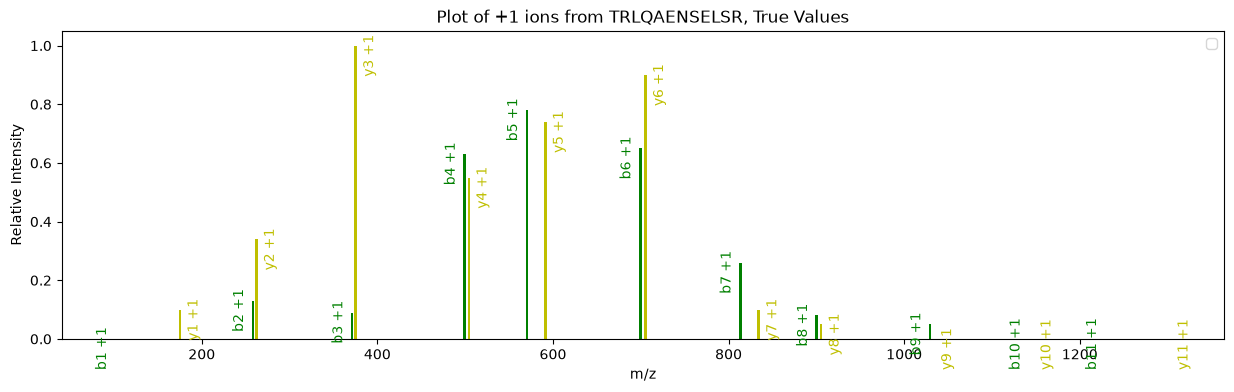

In [31]:
fig, ax = plt.subplots(figsize=(15,4))

plt.xlabel('m/z')
plt.ylabel('Relative Intensity')
plt.title(f'Plot of +1 ions from {sequence}, True Values')

plt.bar(b1_mz, b1_ions_true, width=3, color='g')
for xi, yi, text, in zip(b1_mz, b1_ions_true, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'g'
    )

plt.bar(y1_mz, y1_ions_true, width=3, color='y')
for xi, yi, text, in zip(y1_mz, y1_ions_true, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (5, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'y'
    )

plt.legend()

C:\Users\cassa\AppData\Local\Temp\ipykernel_29004\3677641818.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


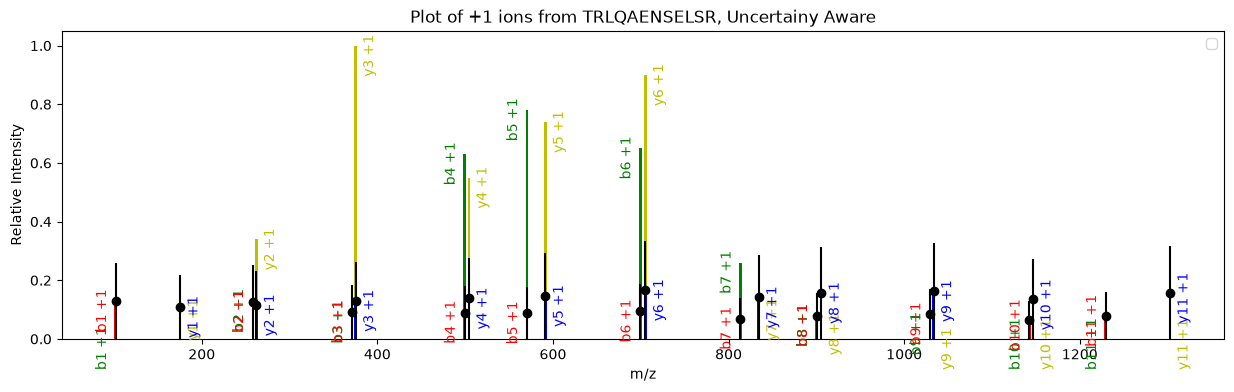

In [32]:
fig, ax = plt.subplots(figsize=(15,4))

plt.xlabel('m/z')
plt.ylabel('Relative Intensity')
plt.title(f'Plot of +1 ions from {sequence}, Uncertainy Aware')

plt.bar(b1_mz, b1_ions_true, width=3, color='g')
for xi, yi, text, in zip(b1_mz, b1_ions_true, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'g'
    )

plt.bar(y1_mz, y1_ions_true, width=3, color='y')
for xi, yi, text, in zip(y1_mz, y1_ions_true, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (5, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'y'
    )

plt.bar(b1_mz, b1_ions_mean, width=3, color='r')
plt.errorbar(b1_mz, b1_ions_mean, yerr=[b1_ions_var_lower, b1_ions_var], fmt='o', color='black')
for xi, yi, text, in zip(b1_mz, b1_ions_mean, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'r'
    )

plt.bar(y1_mz, y1_ions_mean, width=3, color='b')
plt.errorbar(y1_mz, y1_ions_mean, yerr=[y1_ions_var_lower, y1_ions_var], fmt='o', color='black')
for xi, yi, text, in zip(y1_mz, y1_ions_mean, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (5, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'b'
    )

plt.legend()
#plt.bar(y_mz, y_ions_mean, color='b')

C:\Users\cassa\AppData\Local\Temp\ipykernel_29004\174930910.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


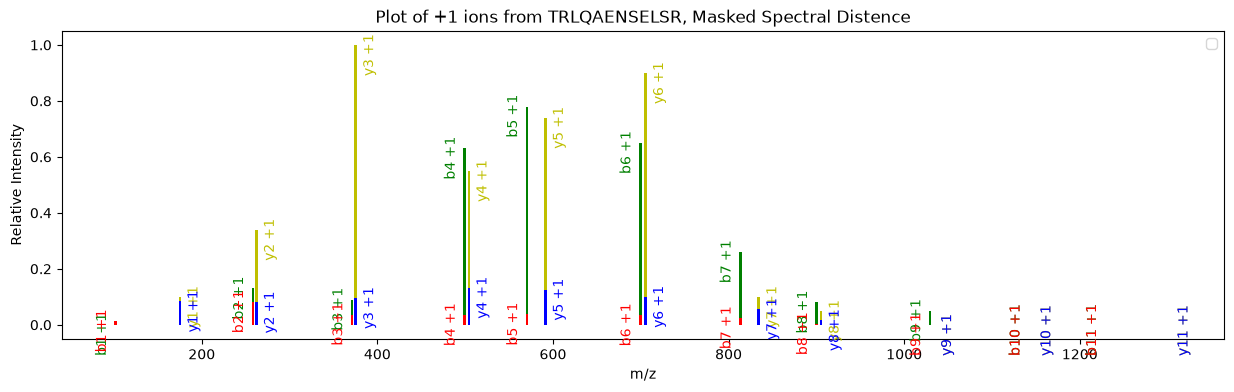

In [33]:
fig, ax = plt.subplots(figsize=(15,4))

plt.xlabel('m/z')
plt.ylabel('Relative Intensity')
plt.title(f'Plot of +1 ions from {sequence}, Masked Spectral Distence')

plt.bar(b1_mz, b1_MSD_ions_true, width=3, color='g')
for xi, yi, text, in zip(b1_mz, b1_MSD_ions_true, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'g'
    )

plt.bar(y1_mz, y1_MSD_ions_true, width=3, color='y')
for xi, yi, text, in zip(y1_mz, y1_MSD_ions_true, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (5, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'y'
    )

plt.bar(b1_mz, b1_MSD_ions_mean, width=3, color='r')
for xi, yi, text, in zip(b1_mz, b1_MSD_ions_mean, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'r'
    )

plt.bar(y1_mz, y1_MSD_ions_mean, width=3, color='b')
for xi, yi, text, in zip(y1_mz, y1_MSD_ions_mean, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (5, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'b'
    )

plt.legend()
#plt.bar(y_mz, y_MSD_ions_mean, color='b')